In [1]:
import numpy as np
import pandas as pd

In [2]:
df_transfers = pd.read_parquet('data/transfers_20000000.parquet',engine='pyarrow')
df_txs = pd.read_parquet('data/txs_20000000.parquet',engine='pyarrow')
df_zeromev = pd.read_parquet('data/zeromev_20000000.parquet',engine='pyarrow')

In [3]:
df_transfers.head()

,blockNum,uniqueId,hash,from,to,value,erc721TokenId,erc1155Metadata,tokenId,asset,category,rawContract.value,rawContract.address,rawContract.decimal,metadata.blockTimestamp
0,0x1312d00,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0x6b75d8af000000e20b7a7ddf000ba900b4009a80,0x4fc47579ecf6aa76677ee142b6b75faf9eeafba8,1.761910e-02,None,None,None,WETH,erc20,0x3e987a00000000,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,0x12,2024-06-01T22:36:47.000Z
1,0x1312d00,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0x4fc47579ecf6aa76677ee142b6b75faf9eeafba8,0x6b75d8af000000e20b7a7ddf000ba900b4009a80,2.692367e+04,None,None,None,RAZE,erc20,0x05b38902000000000000,0x5eaa69b29f99c84fe5de8200340b4e9b4ab38eac,0x12,2024-06-01T22:36:47.000Z
2,0x1312d00,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0x6b75d8af000000e20b7a7ddf000ba900b4009a80,0xfd433bb7e98de56bb4422acd3eb6f174bac52fc9,7.286454e+09,None,None,None,BEW,erc20,0x178b36920000000000000000,0x0f4dbc08b8917c4d683cb55511936989dee1f736,0x12,2024-06-01T22:36:47.000Z
3,0x1312d00,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0xfd433bb7e98de56bb4422acd3eb6f174bac52fc9,0x6b75d8af000000e20b7a7ddf000ba900b4009a80,2.688738e-01,None,None,None,WETH,erc20,0x03bb3b4d00000000,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,0x12,2024-06-01T22:36:47.000Z
4,0x1312d00,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0x6b75d8af000000e20b7a7ddf000ba900b4009a80,0xe3cc21af229934034b320502fa55cfa1ab7b1493,1.016151e+00,None,None,None,WETH,erc20,0x0e1a182c00000000,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,0x12,2024-06-01T22:36:47.000Z


In [4]:
df_txs.head()

,Transaction_Hash,Method,Block,Date_Time,Age,Description,From,Dir,To,Value,Txn_Fee,Gas_Price,Method_full,From_full,To_full,From_sign,To_sign,Txn_sign
0,0xb79b64182236284ad6753e1b5f506e7e6989912c2588...,Transfer,20000000,2024-06-01 22:36:47,209 days ago,1717281407,beaverbuild,None,0x4beFa2aA...045269E9d,0.023212408 ETH\n$77.42,0.000139,4.93695771,Transfer,beaverbuild\n(0x95222290dd7278aa3ddd389cc1e1d1...,0x4befa2aa9c305238aa3e0b5d17eb20c045269e9d,None,Contract,None
1,0xdff838df7e0dccd9d9864a6651dd10abb705b36a1e46...,Multicall,20000000,2024-06-01 22:36:47,209 days ago,1717281407,0x9ACCd33C...dD4A7CaFe,None,Uniswap V3: Positions NFT,0 ETH\n$0.00,0.001217,4.98545771,Multicall,0x9accd33c5a81ffe084036f6b68d8f4cdd4a7cafe,Uniswap V3: Positions NFT\n(0xc36442b4a4522e87...,None,Contract,None
2,0x9f981fa58dfe6917acd564512e2abca4a68d6f580770...,Transfer,20000000,2024-06-01 22:36:47,209 days ago,1717281407,0xd5e66C5A...11aA607cf,None,0xd761Dd69...E8689E6f3,0.026889297 ETH\n$89.69,0.000105,4.98545771,Transfer,0xd5e66c5a5b991a312ff8f970216417411aa607cf,0xd761dd69c7d9e4173938604b3c42910e8689e6f3,None,None,None
3,0x50bd65296866beeeb572d02607d73777db00a43740a8...,Withdraw,20000000,2024-06-01 22:36:47,209 days ago,1717281407,0xaA8167dE...Ba085C8A7,None,0x0e42acBD...e79fBD58E,0 ETH\n$0.00,0.001022,4.98545771,Withdraw,0xaa8167de65ac8951492fc20b43929a2ba085c8a7,0x0e42acbd23faee03249daff896b78d7e79fbd58e,None,Contract,None
4,0xd9a25ed6b5b19fb315a4e638ab2b9849758fbb423b1b...,Execute,20000000,2024-06-01 22:36:47,209 days ago,1717281407,fuckinjeet.eth,None,Uniswap: Universal Router,"3 ETH\n$10,006.37",0.000775,4.98545771,Execute,fuckinjeet.eth<br/>(0x5c34e725cca657f02c1d81fb...,Uniswap: Universal Router\n(0x3fc91a3afd70395c...,ENS Name,Contract,None


In [5]:
df_zeromev.head()

,block_number,tx_index,mev_type,protocol,user_loss_usd,extractor_profit_usd,user_swap_volume_usd,user_swap_count,extractor_swap_volume_usd,extractor_swap_count,imbalance,address_from,address_to,arrival_time_us,arrival_time_eu,arrival_time_as
0,20000900,0,frontrun,uniswap2,NaN,NaN,1604.68,2.0,1814.7,1.0,NaN,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x6b75d8af000000e20b7a7ddf000ba900b4009a80,2024-06-02T01:48:29.424962+00:00,2024-06-02T01:42:28.972146+00:00,2024-06-02T01:37:14.132835+00:00
1,20000900,1,sandwich,uniswap2,NaN,NaN,598.85,1.0,NaN,NaN,NaN,0xb089deca2d6a6703375a9dc5257b48be1237ffb1,0x80a64c6d7f12c47b7c66c5b4e20e72bc1fcd5d9e,2024-06-02T01:37:00.244409+00:00,2024-06-02T01:36:59.488077+00:00,2024-06-02T01:36:59.243578+00:00
2,20000900,2,swap,uniswap2,NaN,NaN,991.31,1.0,NaN,NaN,NaN,0xa76c0541482faccb03d980b011742d16ca90953b,0x1111111254eeb25477b68fb85ed929f73a960582,2024-06-02T01:37:09.274978+00:00,2024-06-02T01:37:08.981456+00:00,2024-06-02T01:37:08.978914+00:00
3,20000900,3,swap,uniswap3,NaN,NaN,48858.54,1.0,NaN,NaN,NaN,0x87199e39fe8826a0688e08420e8fc21094a6de60,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,2024-06-02T01:48:29.424962+00:00,2024-06-02T01:42:28.972146+00:00,2024-06-02T01:37:10.773198+00:00
4,20000900,4,swap,uniswap2,NaN,NaN,434.18,1.0,NaN,NaN,NaN,0x5e898d6ddc2a24dfbd3ad5acf0ce84321950c48a,0x881d40237659c251811cec9c364ef91dc08d300c,2024-06-02T01:37:06.894931+00:00,2024-06-02T01:37:05.593038+00:00,2024-06-02T01:37:06.263584+00:00


In [6]:
df_account = pd.read_csv('data/account_labels.csv')
df_token = pd.read_csv('data/token_labels.csv')

In [7]:
df_account.head()

,address,name,group,sign,etherscan,dawsbot,brianleect,other_name,labels
0,0x0000000000000000000000000000000000000000,Null: 0x000...000,Null,NaN,True,True,True,['Null Address: 0x000...000'],['blocked' 'burn' 'genesis']
1,0x0000000000000000000000000000000000000001,Null: 0x000...001,Null,NaN,True,True,True,['Null Address: 0x000...001'],['blocked' 'burn']
2,0x0000000000000000000000000000000000000002,Null: 0x000...002,Null,NaN,NaN,True,True,NaN,['burn' 'genesis']
3,0x0000000000000000000000000000000000000003,Null: 0x000...003,Null,NaN,NaN,True,True,NaN,['burn' 'genesis']
4,0x0000000000000000000000000000000000000004,Null: 0x000...004,Null,NaN,NaN,True,True,NaN,['burn' 'genesis']


In [8]:
df_token.head()

,#,Token,Symbol,Address,Reputation,Labels,Symbol_lower,Rank,Asset,Symbol_y,Price,Marketcap,Category,Sector,Tags,similarity,type,Category_clean,duplicated
0,0.0,Ethereum,ETH,ETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cryptocurrency,Cryptocurrency,NaN,NaN,ETH,Networks,NaN
1,1.0,Tether USD,USDT,0xdac17f958d2ee523a2206206994597c13d831ec7,OK,"['Tether', 'Stablecoin']",usdt,3.0,Tether,USDT,$1.00,$153B,Cryptocurrency,Stablecoins,"['Centralized Issuer', 'U.S. Dollar Stablecoin']",100.0,Cryptocurrency,Stablecoins,True
2,2.0,BNB,BNB,0xb8c77482e45f1f44de1745f52c74426c631bdd52,OK,"['Binance', 'Mainnet Launched']",bnb,5.0,BNB,BNB,$659.54,$93.29B,Networks,Smart Contract Platform,"['CeFi', 'Centralized Exchange']",100.0,Protocol,Networks,NaN
3,3.0,USDC,USDC,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,OK,"['Circle', 'Stablecoin']",usdc,7.0,USDC,USDC,$1.00,$61.73B,Cryptocurrency,Stablecoins,"['Centralized Issuer', 'U.S. Dollar Stablecoin']",100.0,Cryptocurrency,Stablecoins,True
4,4.0,stETH,stETH,0xae7ab96520de3a18e5e111b5eaab095312d7fe84,OK,"['Lido', 'Liquid staking', 'Beacon Depositor']",steth,11.0,Lido Staked Ether,stETH,"$2,487.88",$22.44B,Synthetic Assets,Liquid Staking Tokens,['Ethereum Liquid Staking Asset'],22.0,Synthetic,Liquid Staking Tokens,True


---
# EDA: Spam Token Detection
The goal is to understand the structure of the transfer data and identify signals that distinguish spam tokens from legitimate ones. We work at the **contract address level** — each unique `rawContract.address` is a token, and we aggregate transfer-level data to build token-level features.

## 1. Dataset Overview & Null Analysis

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('=== df_transfers ===')
print(f'Shape: {df_transfers.shape}')
print('\nNull counts:')
print(df_transfers.isnull().sum())
print('\nDtype summary:')
print(df_transfers.dtypes)

=== df_transfers ===
Shape: (3654710, 15)

Null counts:
blockNum                         0
uniqueId                         0
hash                             0
from                             0
to                              60
value                       270552
erc721TokenId              3597573
erc1155Metadata            3442578
tokenId                    3597540
asset                        29205
category                         0
rawContract.value           269302
rawContract.address        1493397
rawContract.decimal         267613
metadata.blockTimestamp          0
dtype: int64

Dtype summary:
blockNum                    object
uniqueId                    object
hash                        object
from                        object
to                          object
value                      float64
erc721TokenId               object
erc1155Metadata             object
tokenId                     object
asset                       object
category                    object
rawCo

In [10]:
print('=== df_token ===')
print(f'Shape: {df_token.shape}')
print(f'Verified contract addresses (non-ETH): {df_token["Address"].str.startswith("0x", na=False).sum()}')
print(f'Unique symbols: {df_token["Symbol"].nunique()}')

print('\n=== df_account ===')
print(f'Shape: {df_account.shape}')
print(f'Unique groups:\n{df_account["group"].value_counts().head(10)}')

=== df_token ===
Shape: (2713, 19)
Verified contract addresses (non-ETH): 2712
Unique symbols: 2516

=== df_account ===
Shape: (368555, 9)
Unique groups:
group
Uniswap V2               6690
SushiSwap                3978
Endaoment                3291
Balancer                 2970
Multichain Hack Alert    2680
MEV Bot                  1679
Bancor                    949
Synthetix                 551
Pimlico                   357
Aave                      314
Name: count, dtype: int64


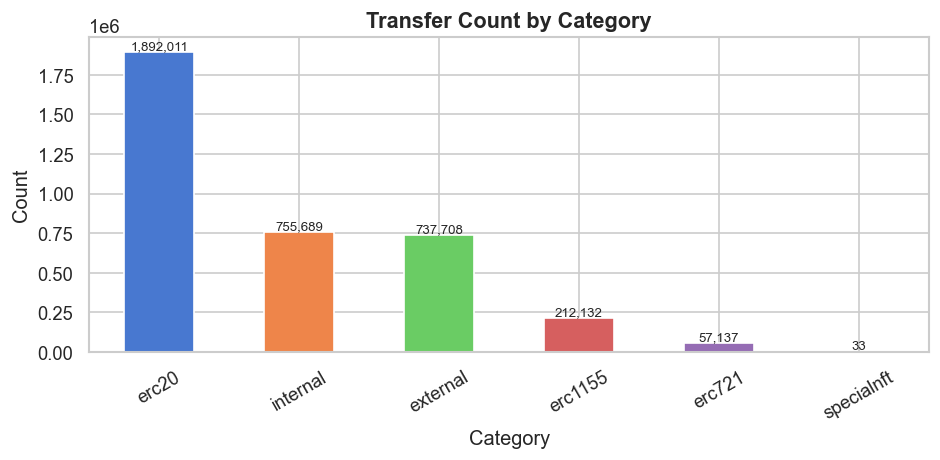

category
erc20         1892011
internal       755689
external       737708
erc1155        212132
erc721          57137
specialnft         33
Name: count, dtype: int64


In [11]:
# Transfer category breakdown
cat_counts = df_transfers['category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
cat_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(cat_counts)))
ax.set_title('Transfer Count by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
print(cat_counts)

## 2. Label Construction
We identify **verified tokens** from `token_labels.csv` using their contract address. Any token whose `rawContract.address` is **not** in the verified list is a spam candidate. Tokens that also **collide on symbol** with a verified token (same symbol, different address) are flagged as high-confidence spam.

In [12]:
# Build verified address set (lowercase for safe matching)
verified_addresses = set(
    df_token[df_token['Address'].str.startswith('0x', na=False)]['Address'].str.lower()
)
# Build verified symbol -> canonical address mapping
verified_symbol_map = (
    df_token[df_token['Address'].str.startswith('0x', na=False)]
    .set_index('Symbol')['Address']
    .str.lower()
    .to_dict()
)

# Work only on token transfers (ignore external/internal which have no contract)
df_tok = df_transfers[
    df_transfers['category'].isin(['erc20', 'token', 'erc721', 'erc1155', 'specialnft'])
].copy()
df_tok['contract_addr'] = df_tok['rawContract.address'].str.lower()
df_tok['asset_upper'] = df_tok['asset'].str.upper()

# Label at transfer level
df_tok['is_verified'] = df_tok['contract_addr'].isin(verified_addresses).astype(int)

# Flag symbol collision: same symbol as verified token but DIFFERENT address
def check_collision(row):
    sym = row['asset_upper']
    addr = row['contract_addr']
    if not isinstance(sym, str) or not isinstance(addr, str):
        return 0
    canonical = verified_symbol_map.get(sym)
    return 1 if (canonical and canonical != addr) else 0

df_tok['symbol_collision'] = df_tok.apply(check_collision, axis=1)

print(f'Token-category transfers:  {len(df_tok):,}')
print(f'Verified transfers:        {df_tok["is_verified"].sum():,} ({df_tok["is_verified"].mean():.1%})')
print(f'Unverified transfers:      {(1-df_tok["is_verified"]).sum():,} ({(1-df_tok["is_verified"]).mean():.1%})')
print(f'Symbol collision transfers:{df_tok["symbol_collision"].sum():,}')

Token-category transfers:  2,161,313
Verified transfers:        1,569,451 (72.6%)
Unverified transfers:      591,862 (27.4%)
Symbol collision transfers:426,293


Total unique token contracts:       12,356
  Verified (legit):                 1,599 (12.9%)
  Unverified (potential spam):      10,757 (87.1%)
  Symbol collision (high-conf spam):2,111


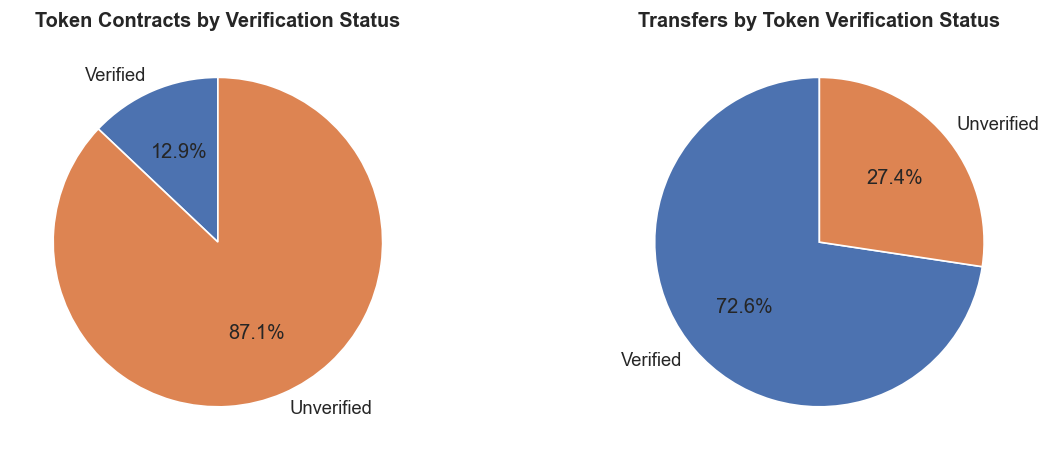

In [13]:
# Unique token contracts
total_contracts     = df_tok['contract_addr'].nunique()
verified_contracts  = df_tok[df_tok['is_verified']==1]['contract_addr'].nunique()
unverified_contracts= df_tok[df_tok['is_verified']==0]['contract_addr'].nunique()
collision_contracts = df_tok[df_tok['symbol_collision']==1]['contract_addr'].nunique()

print(f'Total unique token contracts:       {total_contracts:,}')
print(f'  Verified (legit):                 {verified_contracts:,} ({verified_contracts/total_contracts:.1%})')
print(f'  Unverified (potential spam):      {unverified_contracts:,} ({unverified_contracts/total_contracts:.1%})')
print(f'  Symbol collision (high-conf spam):{collision_contracts:,}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (v, u, title) in zip(axes, [
    (verified_contracts, unverified_contracts, 'Token Contracts by Verification Status'),
    (df_tok['is_verified'].sum(), (1-df_tok['is_verified']).sum(), 'Transfers by Token Verification Status')
]):
    ax.pie([v, u], labels=['Verified', 'Unverified'], autopct='%1.1f%%',
           colors=['#4C72B0', '#DD8452'], startangle=90)
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Symbol Collision Analysis
Spam tokens impersonate well-known tokens by reusing the same symbol (e.g. a fake `USDC` with a different contract address). This is the most direct spam signal in the dataset.

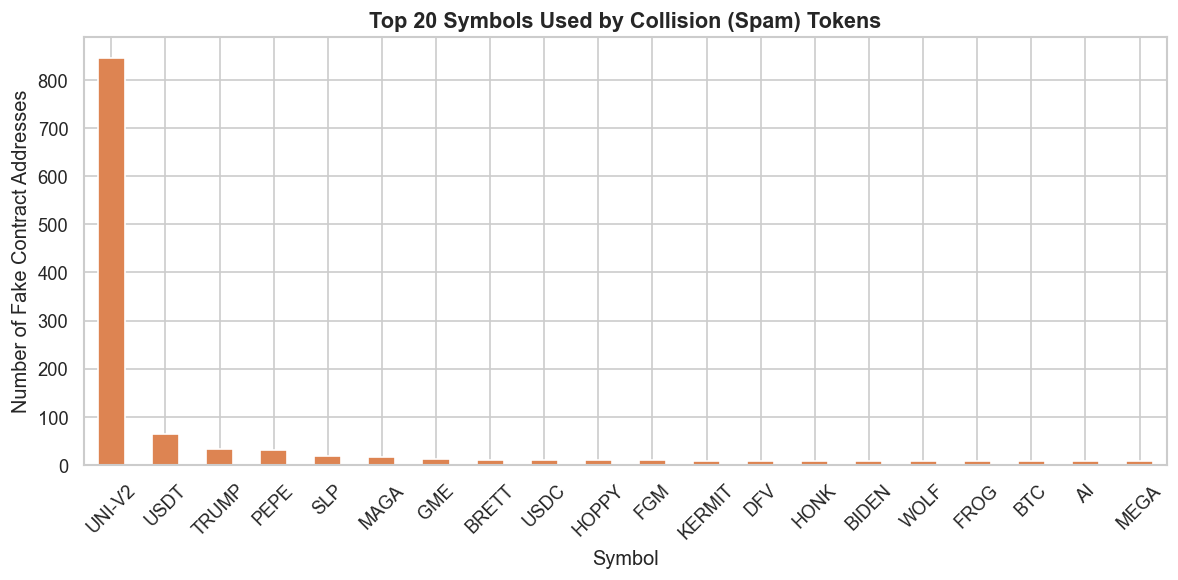


Sample collision tokens (same symbol, different contract from verified):
   asset                              contract_addr
    USDT 0xdac17f958d2ee523a2206206994597c13d831ec7
    USDC 0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48
    LOOM 0x42476f744292107e34519f9c357927074ea3f75d
    VOLT 0x7f792db54b0e580cdc755178443f0430cf799aca
   TRUMP 0x576e2bed8f7b46d34016198911cdf9886f78bea7
    WETH 0xe0b469cb3eda0ece9e425cfeda4df986a55ea9f8
   DIONE 0x89b69f2d1adffa9a253d40840b6baa7fc903d697
   HOPPY 0x6e79b51959cf968d87826592f46f819f92466615
BOYSCLUB 0x2d9996f3b9d2e73540fdbfdfe81d71e9e08cbf03
   TURBO 0xa35923162c49cf95e6bf26623385eb431ad920d3
    PEPE 0x6982508145454ce325ddbe47a25d4ec3d2311933
    WOLF 0x67466be17df832165f8c80a5a120ccc652bd7e69
  UNI-V2 0xd9e5a2c27ae9dc374672b350cb660c8bd337a7a0
    MAGA 0xd29da236dd4aac627346e1bba06a619e8c22d7c5
 PEPE2.0 0xfb66321d7c674995dfcc2cb67a30bc978dc862ad


In [14]:
collisions = df_tok[df_tok['symbol_collision'] == 1][['asset', 'contract_addr']].drop_duplicates()
collision_counts = collisions['asset'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
collision_counts.plot(kind='bar', ax=ax, color='#DD8452')
ax.set_title('Top 20 Symbols Used by Collision (Spam) Tokens', fontsize=13, fontweight='bold')
ax.set_xlabel('Symbol')
ax.set_ylabel('Number of Fake Contract Addresses')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nSample collision tokens (same symbol, different contract from verified):')
print(collisions.head(15).to_string(index=False))

## 4. Token-Level Feature Aggregation
We collapse the transfer table to the **contract address level** and compute behavioral features for each token.

In [15]:
from scipy.stats import entropy as scipy_entropy

# Convert blockNum hex -> int for block spread
df_tok['block_int'] = df_tok['blockNum'].apply(lambda x: int(x, 16) if isinstance(x, str) else x)

def cat_entropy(x):
    counts = x.value_counts(normalize=True)
    return scipy_entropy(counts)

token_features = df_tok.groupby('contract_addr').agg(
    n_transfers        = ('hash', 'count'),
    n_unique_senders   = ('from', 'nunique'),
    n_unique_receivers = ('to', 'nunique'),
    value_mean         = ('value', 'mean'),
    value_std          = ('value', 'std'),
    value_null_ratio   = ('value', lambda x: x.isnull().mean()),
    n_distinct_blocks  = ('block_int', 'nunique'),
    symbol_collision   = ('symbol_collision', 'max'),
    is_verified        = ('is_verified', 'max'),
    category_entropy   = ('category', cat_entropy),
    asset              = ('asset', 'first'),
).reset_index()

# Derived features
token_features['sender_receiver_ratio'] = (
    token_features['n_unique_senders'] / token_features['n_unique_receivers'].replace(0, 1)
)
token_features['transfers_per_block'] = (
    token_features['n_transfers'] / token_features['n_distinct_blocks'].replace(0, 1)
)

# Label: 1=legit (verified), 0=spam (symbol collision), NaN=unlabeled
token_features['label'] = token_features.apply(
    lambda r: 1 if r['is_verified'] == 1 else (0 if r['symbol_collision'] == 1 else float('nan')),
    axis=1
)

labeled = token_features.dropna(subset=['label'])
print(f'Total unique token contracts: {len(token_features):,}')
print(f'Labeled tokens:               {len(labeled):,}')
print(f'  Legit  (label=1):           {(labeled["label"]==1).sum():,}')
print(f'  Spam   (label=0):           {(labeled["label"]==0).sum():,}')
token_features.head()

Total unique token contracts: 12,356
Labeled tokens:               3,606
  Legit  (label=1):           1,599
  Spam   (label=0):           2,007


,contract_addr,n_transfers,n_unique_senders,n_unique_receivers,value_mean,value_std,value_null_ratio,n_distinct_blocks,symbol_collision,is_verified,category_entropy,asset,sender_receiver_ratio,transfers_per_block,label
0,0x000000000000003607fce1ac9e043a86675c5c2f,1,1,1,NaN,NaN,1.0,1,0,0,0.0,Ͼ721,1.0,1.000000,NaN
1,0x00000000000009ca62911fdd88c8cf50565ab183,1,1,1,NaN,NaN,1.0,1,0,0,0.0,FTTKN,1.0,1.000000,NaN
2,0x0000000000003f07248ddfb9821770a8200ef77d,13,9,9,NaN,NaN,1.0,13,0,0,0.0,SPW,1.0,1.000000,NaN
3,0x000000000000d0151e748d25b766e77efe2a6c83,3,3,3,5692.597174,5815.163161,0.0,2,0,0,0.0,XDEX,1.0,1.500000,NaN
4,0x000000000002c0b7dfdf4e6a7d53aeb8889b80bf,8,7,5,NaN,NaN,1.0,7,0,0,0.0,XTREME,1.4,1.142857,NaN


## 5. Feature Distributions: Spam vs. Legit
We compare key features between labeled spam and legit tokens to confirm discriminative power before modeling.

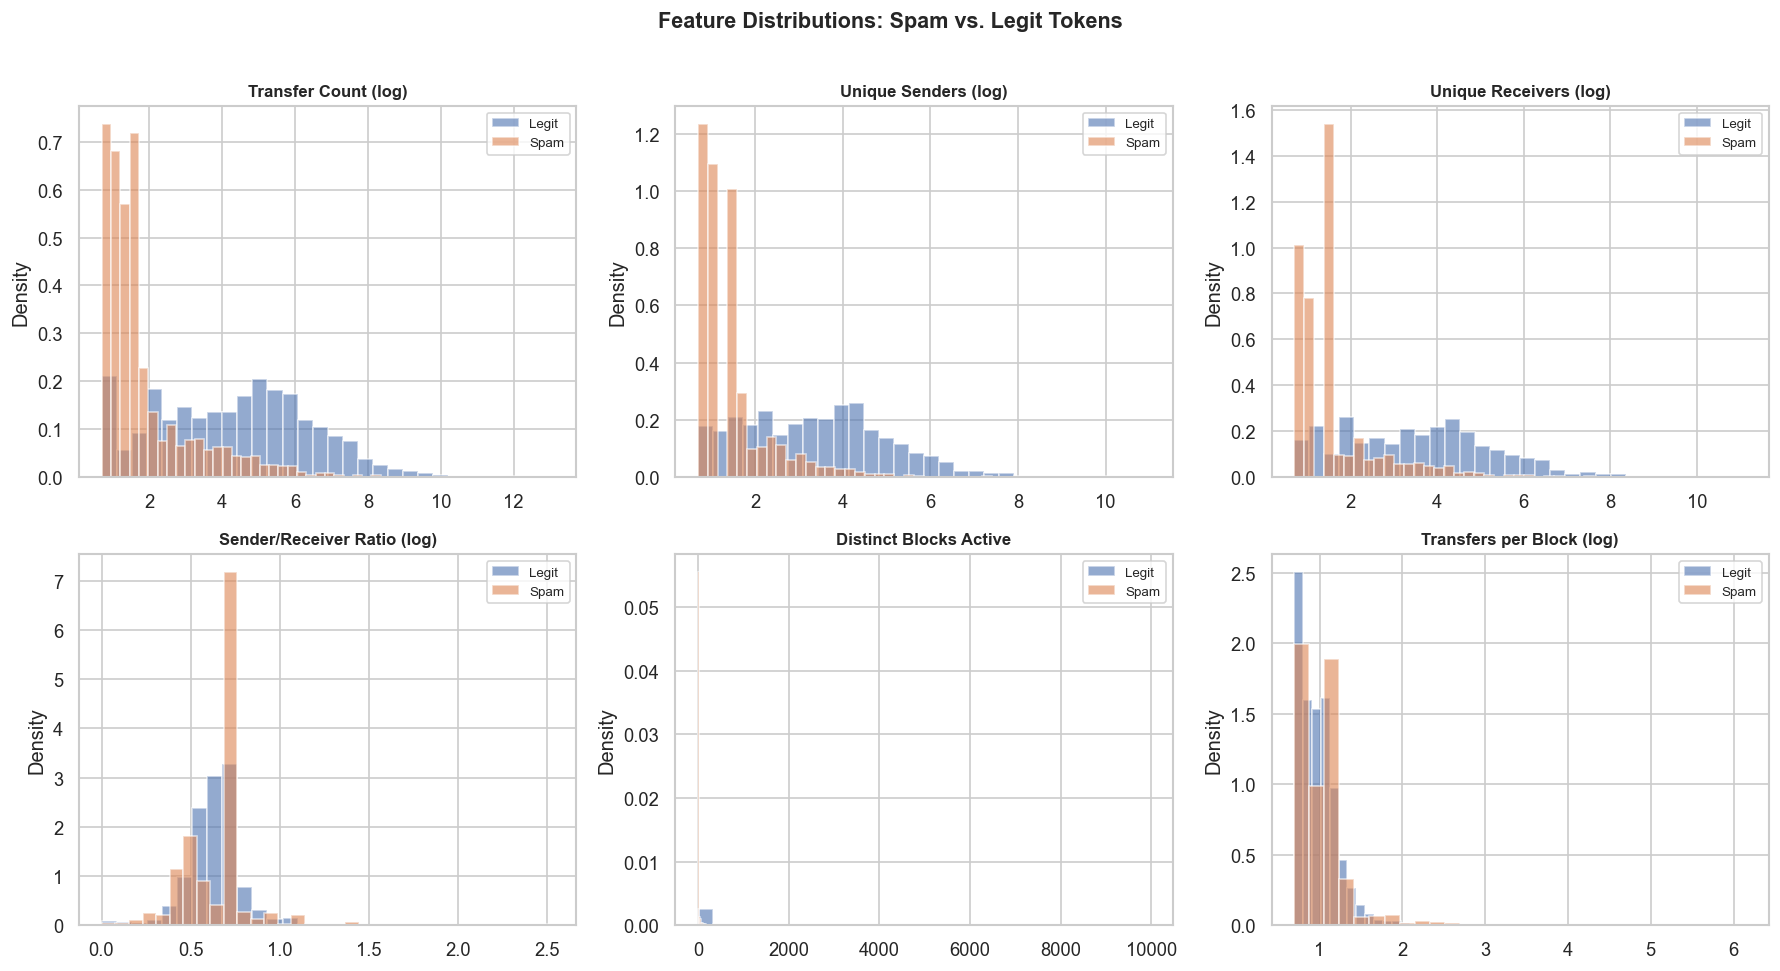

In [16]:
features_to_plot = [
    ('n_transfers',           'Transfer Count (log)',            True),
    ('n_unique_senders',      'Unique Senders (log)',            True),
    ('n_unique_receivers',    'Unique Receivers (log)',          True),
    ('sender_receiver_ratio', 'Sender/Receiver Ratio (log)',     True),
    ('n_distinct_blocks',     'Distinct Blocks Active',          False),
    ('transfers_per_block',   'Transfers per Block (log)',       True),
]

spam  = labeled[labeled['label'] == 0]
legit = labeled[labeled['label'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, title, use_log) in enumerate(features_to_plot):
    ax = axes[i]
    d_spam  = spam[col].dropna()
    d_legit = legit[col].dropna()
    if use_log:
        d_spam  = np.log1p(d_spam)
        d_legit = np.log1p(d_legit)
    ax.hist(d_legit, bins=30, alpha=0.6, label='Legit', color='#4C72B0', density=True)
    ax.hist(d_spam,  bins=30, alpha=0.6, label='Spam',  color='#DD8452', density=True)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Spam vs. Legit Tokens', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Sender/Receiver Ratio Deep Dive
A low sender/receiver ratio (few senders → many receivers) is the canonical airdrop-spam pattern.

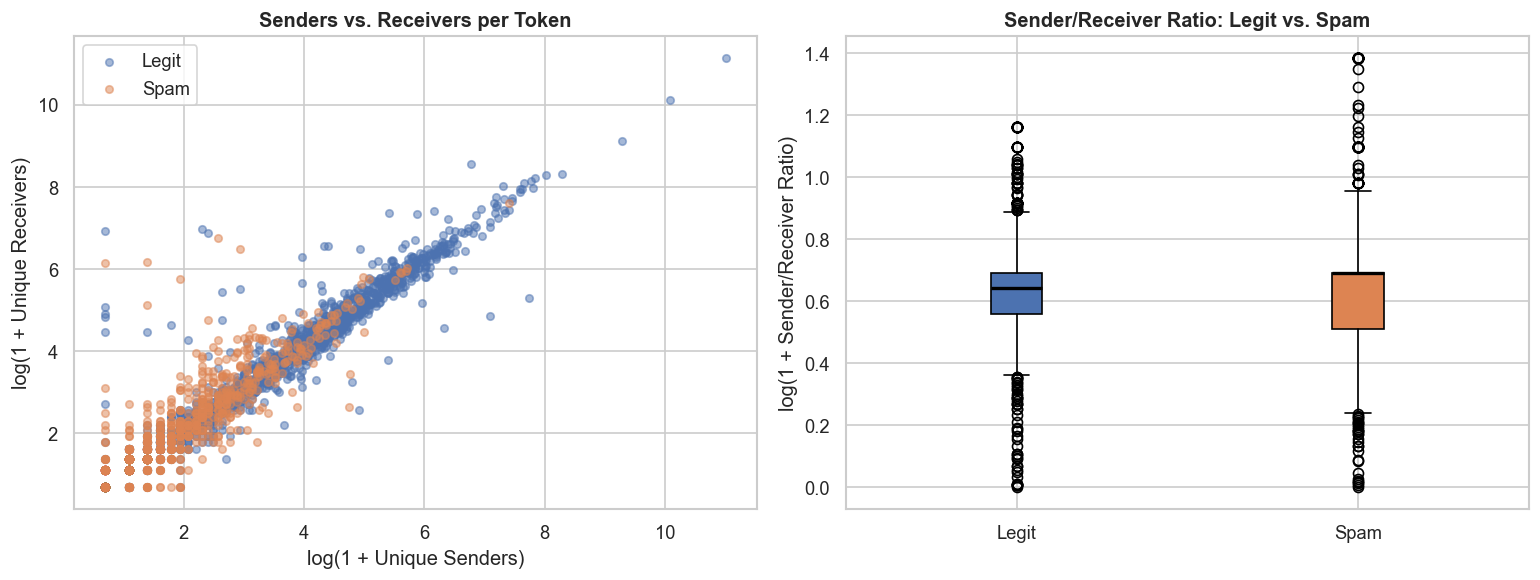

Sender/Receiver Ratio Stats:
Legit: count    1599.0000
mean        0.9366
std         0.5820
min         0.0010
25%         0.7500
50%         0.8995
75%         1.0000
max        11.6531
Name: sender_receiver_ratio, dtype: float64

Spam:  count    2007.0000
mean        0.9332
std         0.4704
min         0.0021
25%         0.6667
50%         1.0000
75%         1.0000
max         8.7692
Name: sender_receiver_ratio, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: senders vs receivers
ax = axes[0]
ax.scatter(np.log1p(legit['n_unique_senders']), np.log1p(legit['n_unique_receivers']),
           alpha=0.5, s=20, label='Legit', color='#4C72B0')
ax.scatter(np.log1p(spam['n_unique_senders']),  np.log1p(spam['n_unique_receivers']),
           alpha=0.5, s=20, label='Spam',  color='#DD8452')
ax.set_xlabel('log(1 + Unique Senders)')
ax.set_ylabel('log(1 + Unique Receivers)')
ax.set_title('Senders vs. Receivers per Token', fontweight='bold')
ax.legend()

# Boxplot of sender/receiver ratio
ax2 = axes[1]
plot_data = [
    np.log1p(legit['sender_receiver_ratio'].clip(upper=legit['sender_receiver_ratio'].quantile(0.99))),
    np.log1p(spam['sender_receiver_ratio'].clip(upper=spam['sender_receiver_ratio'].quantile(0.99)))
]
bp = ax2.boxplot(plot_data, labels=['Legit', 'Spam'], patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#DD8452')
ax2.set_ylabel('log(1 + Sender/Receiver Ratio)')
ax2.set_title('Sender/Receiver Ratio: Legit vs. Spam', fontweight='bold')

plt.tight_layout()
plt.show()

print('Sender/Receiver Ratio Stats:')
print('Legit:', legit['sender_receiver_ratio'].describe().round(4))
print('\nSpam: ', spam['sender_receiver_ratio'].describe().round(4))

## 7. Block Concentration Analysis
Spam tokens are typically deployed and airdropped in a burst — their transfers cluster in very few blocks.

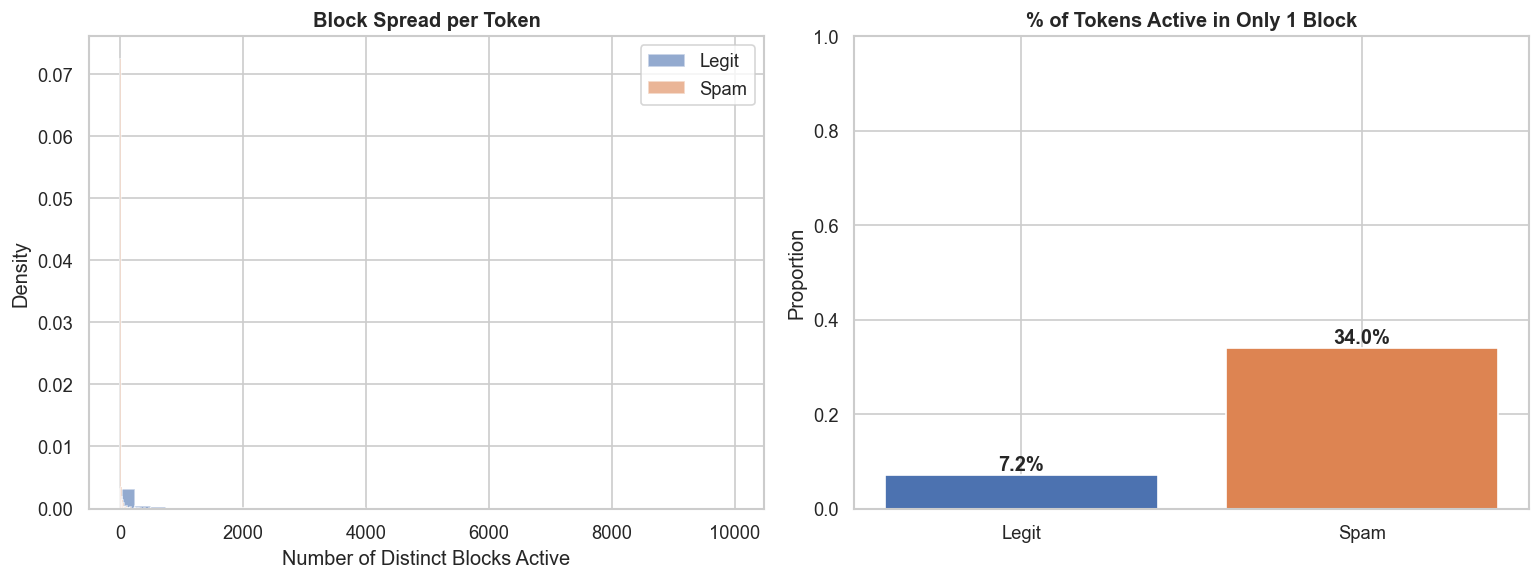

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(legit['n_distinct_blocks'], bins=40, alpha=0.6, label='Legit', color='#4C72B0', density=True)
ax.hist(spam['n_distinct_blocks'],  bins=40, alpha=0.6, label='Spam',  color='#DD8452', density=True)
ax.set_xlabel('Number of Distinct Blocks Active')
ax.set_ylabel('Density')
ax.set_title('Block Spread per Token', fontweight='bold')
ax.legend()

ax2 = axes[1]
single_block_legit = (legit['n_distinct_blocks'] == 1).mean()
single_block_spam  = (spam['n_distinct_blocks']  == 1).mean()
bars = ax2.bar(['Legit', 'Spam'], [single_block_legit, single_block_spam], color=['#4C72B0', '#DD8452'])
for bar, val in zip(bars, [single_block_legit, single_block_spam]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.1%}', ha='center', fontweight='bold')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.set_title('% of Tokens Active in Only 1 Block', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Transfer Value Distribution
Spam airdrops often send identical or near-zero values to many addresses.

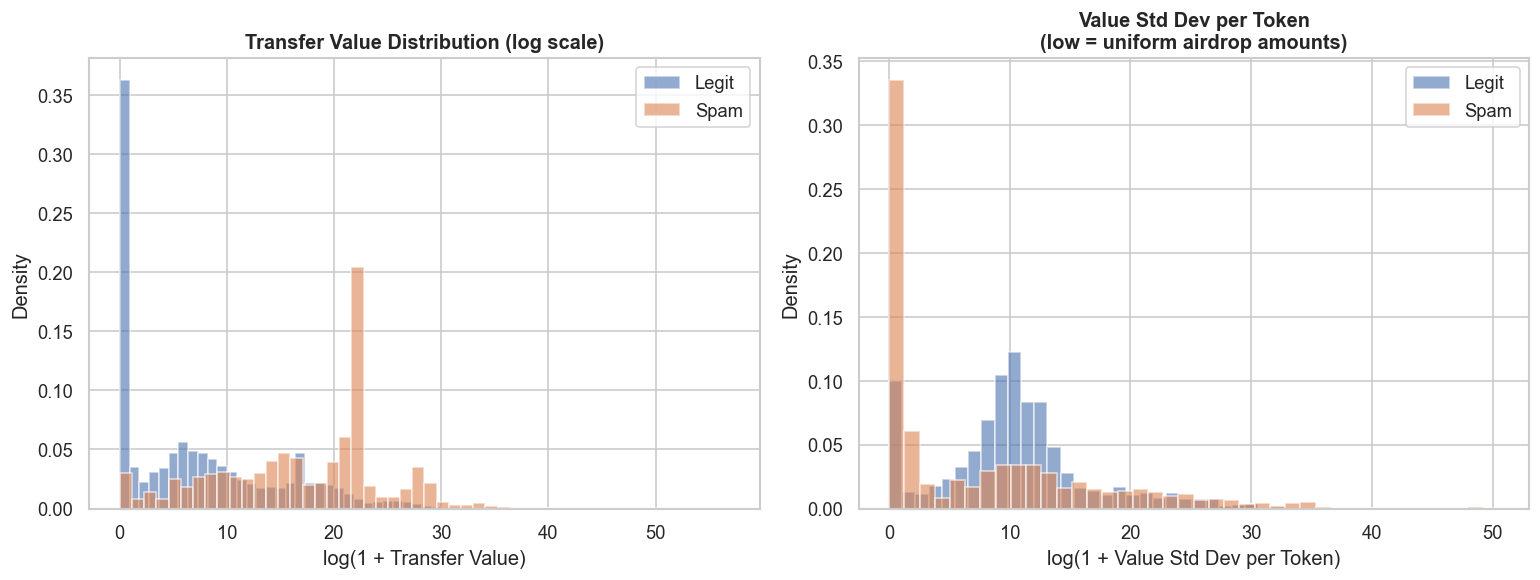

In [19]:
spam_contracts  = set(spam['contract_addr'])
legit_contracts = set(legit['contract_addr'])

spam_vals  = df_tok[df_tok['contract_addr'].isin(spam_contracts)]['value'].dropna()
legit_vals = df_tok[df_tok['contract_addr'].isin(legit_contracts)]['value'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(np.log1p(legit_vals.clip(lower=0)), bins=50, alpha=0.6, label='Legit', color='#4C72B0', density=True)
ax.hist(np.log1p(spam_vals.clip(lower=0)),  bins=50, alpha=0.6, label='Spam',  color='#DD8452', density=True)
ax.set_xlabel('log(1 + Transfer Value)')
ax.set_ylabel('Density')
ax.set_title('Transfer Value Distribution (log scale)', fontweight='bold')
ax.legend()

ax2 = axes[1]
ax2.hist(np.log1p(legit['value_std'].fillna(0)), bins=40, alpha=0.6, label='Legit', color='#4C72B0', density=True)
ax2.hist(np.log1p(spam['value_std'].fillna(0)),  bins=40, alpha=0.6, label='Spam',  color='#DD8452', density=True)
ax2.set_xlabel('log(1 + Value Std Dev per Token)')
ax2.set_ylabel('Density')
ax2.set_title('Value Std Dev per Token\n(low = uniform airdrop amounts)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Sender Address Label Analysis
We check whether transfer senders appear in `account_labels.csv` as known entities (e.g., DEX protocols, MEV bots).

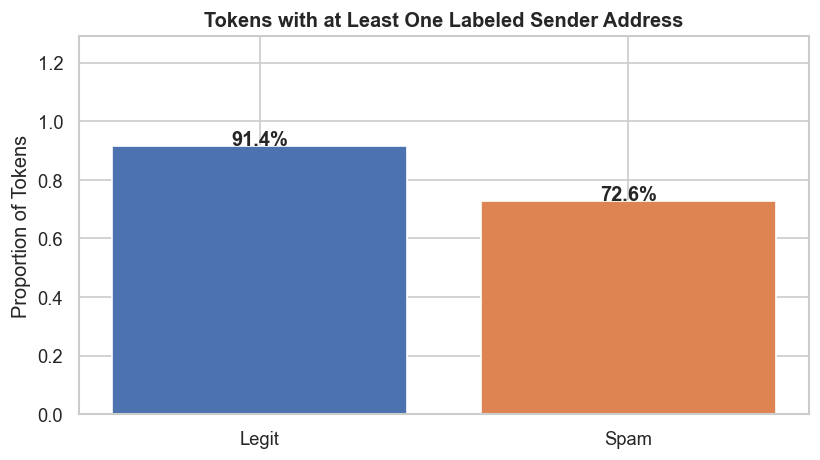

In [20]:
labeled_addresses = set(df_account['address'].str.lower())

sender_label_map = df_tok.groupby('contract_addr')['from'].apply(
    lambda addrs: int(any(str(a).lower() in labeled_addresses for a in addrs))
)
token_features['sender_is_labeled'] = token_features['contract_addr'].map(sender_label_map).fillna(0).astype(int)

# Refresh spam/legit splits with new feature
labeled = token_features.dropna(subset=['label'])
spam  = labeled[labeled['label'] == 0]
legit = labeled[labeled['label'] == 1]

fig, ax = plt.subplots(figsize=(7, 4))
spam_pct  = spam['sender_is_labeled'].mean()
legit_pct = legit['sender_is_labeled'].mean()
bars = ax.bar(['Legit', 'Spam'], [legit_pct, spam_pct], color=['#4C72B0', '#DD8452'])
for bar, val in zip(bars, [legit_pct, spam_pct]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.1%}', ha='center', fontweight='bold')
ax.set_ylabel('Proportion of Tokens')
ax.set_ylim(0, max(legit_pct, spam_pct) * 1.4 + 0.01)
ax.set_title('Tokens with at Least One Labeled Sender Address', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Correlation Matrix of Token-Level Features

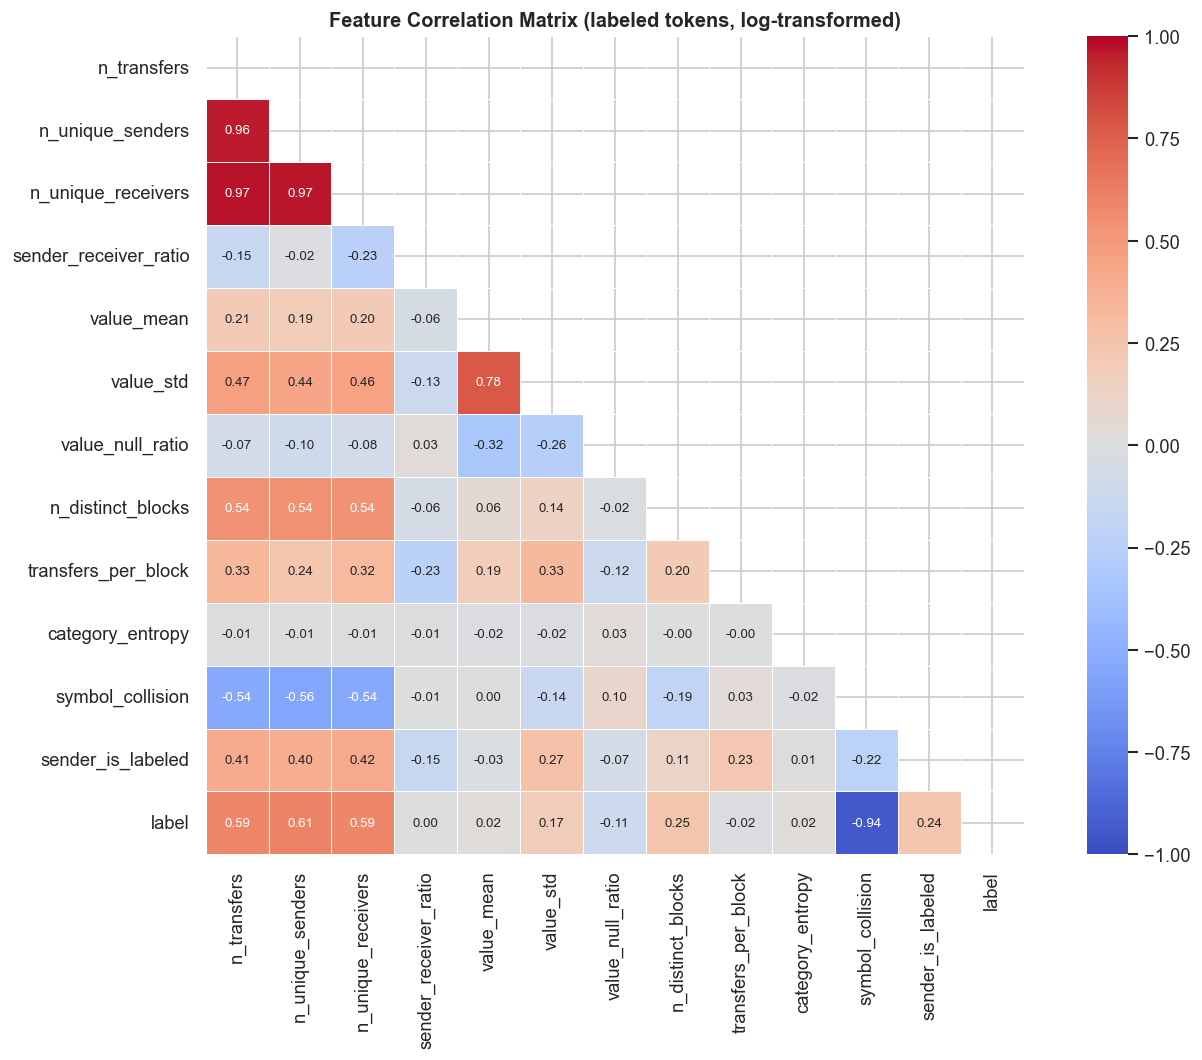


Correlation with label (1=legit, 0=spam):
n_unique_senders         0.608
n_transfers              0.590
n_unique_receivers       0.587
n_distinct_blocks        0.246
sender_is_labeled        0.238
value_std                0.173
value_mean               0.021
category_entropy         0.019
sender_receiver_ratio    0.001
transfers_per_block     -0.019
value_null_ratio        -0.113
symbol_collision        -0.943
Name: label, dtype: float64


In [21]:
numeric_features = [
    'n_transfers', 'n_unique_senders', 'n_unique_receivers',
    'sender_receiver_ratio', 'value_mean', 'value_std',
    'value_null_ratio', 'n_distinct_blocks', 'transfers_per_block',
    'category_entropy', 'symbol_collision', 'sender_is_labeled', 'label'
]

corr_df = labeled[numeric_features].copy()
for col in ['n_transfers', 'n_unique_senders', 'n_unique_receivers',
            'sender_receiver_ratio', 'value_mean', 'value_std', 'transfers_per_block']:
    corr_df[col] = np.log1p(corr_df[col].clip(lower=0).fillna(0))

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (labeled tokens, log-transformed)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with label (1=legit, 0=spam):')
print(corr_matrix['label'].drop('label').sort_values(ascending=False).round(3))

## 11. EDA Summary

| Signal | Direction | Notes |
|---|---|---|
| `symbol_collision` | Spam → 1 | Most direct label signal; by construction |
| `sender_receiver_ratio` | Spam → low | Few senders, many receivers (airdrop pattern) |
| `n_distinct_blocks` | Spam → low | Burst deployment in 1–2 blocks |
| `transfers_per_block` | Spam → high | Dense burst activity |
| `value_std` | Spam → low | Uniform airdrop amounts |
| `value_null_ratio` | Spam → higher | Missing/null contract decimals |
| `sender_is_labeled` | Legit → higher | Known DEX/protocol senders |
| `n_transfers` | Mixed | Spam can be high-volume if widely airdropped |

**Next step:** Use `token_features` as the feature matrix for model training. Use the `label` column (1=legit, 0=spam collision) for supervised learning — rows where `label` is `NaN` are unlabeled and can be excluded or used for semi-supervised extension.